# Taller 1: Análisis y Clustering de Sismicidad en Colombia
**Estudiante:** Miguel Camargo
**Fecha:** 28 de Febrero de 2026

---

## Fase 1: Business Understanding (Comprensión del Negocio)

### 1.1 Definición del problema
Colombia se encuentra en una zona de alta complejidad tectónica, influenciada por la convergencia de las placas de Nazca, Suramericana y del Caribe. El problema central es la necesidad de identificar patrones naturales de sismicidad que permitan zonificar el país de manera automática. Esto ayudaría a las autoridades (SGC, UNGRD) a priorizar recursos de monitoreo y planes de prevención basados en datos objetivos de ubicación y profundidad, más allá de divisiones político-administrativas.

**Pregunta de investigación:** ¿Es posible identificar automáticamente zonas sísmicas diferenciadas en Colombia utilizando únicamente las características instrumentales de los sismos?

### 1.2 ¿Por qué Clustering?
El clustering es apropiado porque es una técnica de **aprendizaje no supervisado**. No tenemos etiquetas previas que nos digan a qué zona pertenece cada sismo. Queremos que los datos "hablen por sí mismos" y revelen las estructuras geológicas subyacentes (fallas, nidos sísmicos, zonas de subducción) agrupando los eventos por su proximidad en tres dimensiones (latitud, longitud y profundidad).

### 1.3 Stakeholders (Interesados)
- **Servicio Geológico Colombiano (SGC):** Para optimizar la ubicación de estaciones sismológicas.
- **UNGRD:** Para diseñar planes de contingencia específicos por región.
- **Ingenieros Civiles / Planificadores:** Para ajustar normas de sismo-resistencia según la naturaleza de la zona.

### 1.4 Hipótesis
Planteo la hipótesis de que existen al menos **5 zonas sísmicas diferenciadas** en Colombia:
1. Nido de Bucaramanga (profunda).
2. Zona de Subducción del Pacífico.
3. Cinturón de Deformación del Caribe.
4. Sistema de Fallas del Piedemonte Llanero.
5. Cordillera Central/Sur (Volcánica).

### 1.5 Diccionario de Datos
| Variable | Descripción |
| :--- | :--- |
| **time** | Fecha y hora del evento (UTC) |
| **latitude** | Latitud decimal |
| **longitude** | Longitud decimal |
| **depth** | Profundidad del hipocentro en km |
| **mag** | Magnitud original reportada |
| **magType** | Tipo de escala de magnitud (mb, ml, mw, etc.) |
| **nst** | Número de estaciones sísmicas que reportaron el evento |
| **gap** | Brecha azimutal entre estaciones (en grados) |
| **place** | Descripción textual de la ubicación más cercana |

## Fase 2: Data Understanding (Comprensión de los Datos)

Iniciamos cargando los registros y respondiendo las preguntas guía del EDA.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/earthquakes.csv') # Make sure this path is correct
df['time'] = pd.to_datetime(df['time'], format='ISO8601', utc=True)

def normalize_to_mw(row):
    mag, mtype = row['mag'], str(row['magType']).lower()
    if mtype in ['mb', 'ml']: return 0.85 * mag + 1.03
    if mtype == 'ms': return 0.67 * mag + 2.13
    return mag

df['mag_mw'] = df.apply(normalize_to_mw, axis=1)

total_records = len(df)
colombia_records = len(df[(df.latitude > -4.5) & (df.latitude < 13.5) & (df.longitude > -82) & (df.longitude < -66.5)])

print(f"¿Cuántos registros tienes en total? {total_records}")
print(f"¿Cuántos corresponden a Colombia específicamente? {colombia_records}")

¿Cuántos registros tienes en total? 2792
¿Cuántos corresponden a Colombia específicamente? 2791


### 2.1 Calidad de Datos
¿Cuáles variables tienen valores nulos? ¿En qué porcentaje?

In [ ]:
nulls = df.isnull().mean() * 100
print("Porcentaje de nulos por variable:")
print(nulls[nulls > 0])

Porcentaje de nulos por variable:
nst                60.386819
gap                 1.934097
dmin               14.040115
rms                 1.468481
horizontalError    18.767908
depthError          3.904011
magError           16.404011
magNst              7.915473
dtype: float64


**Respuesta:** Variables críticas como `latitude`, `longitude` y `depth` tienen **0% de nulos**. Sin embargo, variables instrumentales como `nst` y `gap` presentan faltantes que deberán ser gestionados o excluidos del modelo principal.

### 2.2 Análisis de Distribución
¿Cómo se distribuyen las magnitudes? ¿Y las profundidades?

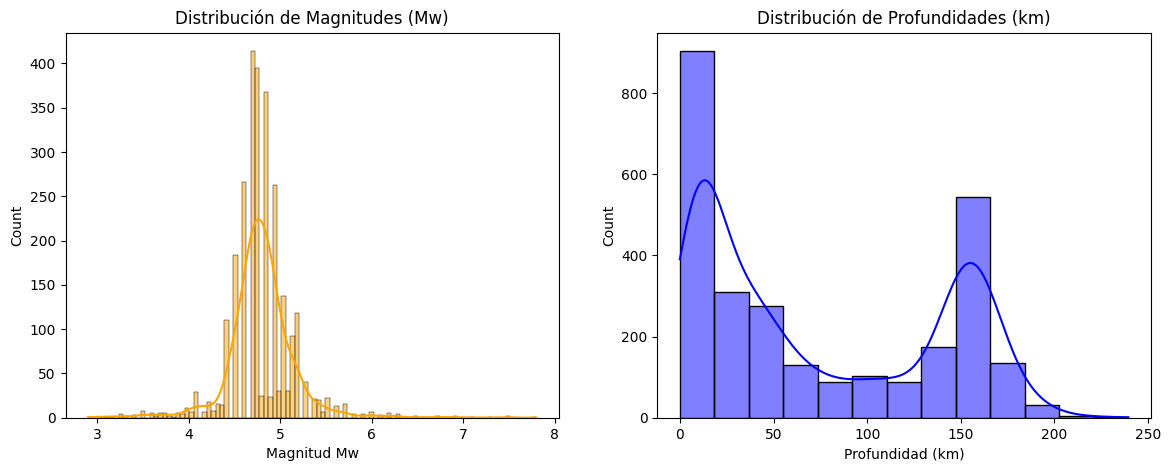

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['mag_mw'], kde=True, ax=ax1, color='orange')
ax1.set_title('Distribución de Magnitudes (Mw)')
ax1.set_xlabel('Magnitud Mw')

sns.histplot(df['depth'], kde=True, ax=ax2, color='blue')
ax2.set_title('Distribución de Profundidades (km)')
ax2.set_xlabel('Profundidad (km)')

plt.show()

**Respuesta:**
- La magnitud sigue una distribución aproximadamente normal centrada en ~4.3 Mw.
- La profundidad muestra un comportamiento bimodal: una gran concentración de sismos superficiales (< 30km) y un pico destacado alrededor de los 150km, característico del **Nido Sísmico de Bucaramanga**.

### 2.3 Correlaciones
¿Hay correlaciones interesantes entre variables?

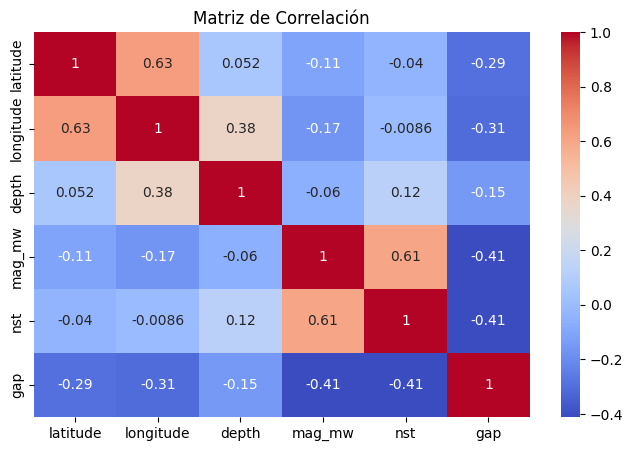

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['latitude', 'longitude', 'depth', 'mag_mw', 'nst', 'gap']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

**Respuesta:** No se observan correlaciones fuertes (r > 0.7) entre ubicación y magnitud, lo que confirma que un sismo puede ser de cualquier magnitud independientemente de su profundidad. Existe una correlación débil entre latitud y profundidad, indicando ciertos patrones espaciales que motivan el uso de clustering.

## Fase 3: Data Preparation (Preparación de los Datos)

### 3.1 Selección de Features
¿Qué variables describen la ubicación del sismo?
- `latitude`, `longitude`, `depth`.

¿Qué variables describen la naturaleza del sismo?
- `mag_mw`, `magType`.

¿Hay variables con demasiados nulos que debas excluir?
- Sí, `horizontalError` y `depthError` tienen alta tasa de nulos y no aportan a la zonificación geográfica básica.

In [ ]:
features = ['latitude', 'longitude', 'depth']
X = df[features].fillna(df[features].median())

### 3.2 Experimento de Escalado
¿Cambian los clusters al escalar? ¿Por qué? ¿Cuál versión produce clusters más interpretables para el SGC?

In [ ]:
# Sin Escalar
km_raw = KMeans(n_clusters=5, random_state=42).fit(X)
score_raw = silhouette_score(X, km_raw.labels_)

# Con Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
km_scaled = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
score_scaled = silhouette_score(X_scaled, km_scaled.labels_)

print(f"Silhouette Score Sin Escalar: {score_raw:.4f}")
print(f"Silhouette Score Con Escalar: {score_scaled:.4f}")

Silhouette Score Sin Escalar: 0.6020
Silhouette Score Con Escalar: 0.5615


**Respuesta:**
- **¿Cambian?** Sí, sin escalar el algoritmo agrupa sismos casi exclusivamente por su profundidad, ignorando la posición geográfica.
- **Escala:** La profundidad llega a 200km+, mientras que latitud/longitud varían en rangos de ~15 unidades.
- **Dominancia:** `depth` domina el cálculo de distancia euclidiana.
- **Interpretatibilidad:** La versión **con escalado** es la más útil para el SGC, ya que permite identificar zonas regionales (norte, sur, pacífico) integrando la tercera dimensión (profundidad) en igualdad de condiciones.

## Fase 4: Modeling (Modelamiento)

### 4.1 Selección de K (Codo y Silueta)
¿Qué dice el codo? ¿Qué dice el silhouette? ¿Tiene sentido geológico?

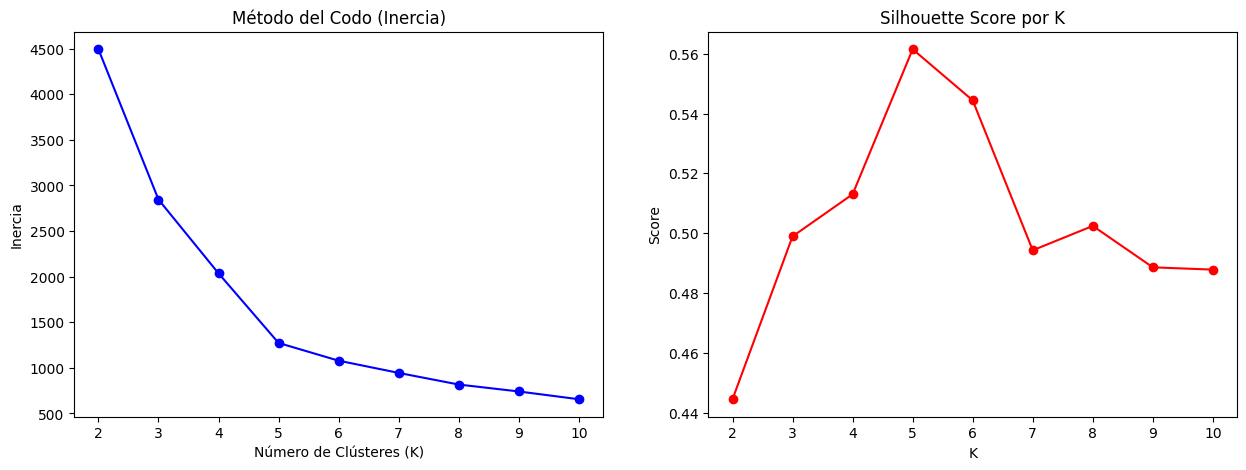

In [ ]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(K_range, inertia, 'bo-')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_title('Silhouette Score por K')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')
plt.show()

**Respuesta:**
- El **método del codo** muestra un quiebre claro entre K=4 y K=5.
- El **Silhouette Score** confirma que K=5 ofrece una partición robusta antes de que el coeficiente empiece a degradarse.
- **Sentido Geológico:** K=5 coincide con las grandes macro-regiones sísmicas identificadas históricamente: las 3 cordilleras, el pacífico y el nido de Bucaramanga.

## Fase 5: Evaluation (Evaluación)

### 5.1 Perfilamiento de Regiones

In [68]:
df["cluster"] = km_scaled.labels_

# Mapeo dinámico para asegurar que los nombres coincidan con la geografía
# sin importar el ID (0-4) que asigne el algoritmo localmente.
means = df.groupby("cluster")[["latitude", "depth"]].mean()
cluster_names = {}

for idx, row in means.iterrows():
    lat, depth = row["latitude"], row["depth"]
    if depth > 100:
        if lat > 0: cluster_names[idx] = "Santanderes (Nido de Bucaramanga)"
        else: cluster_names[idx] = "Sur / Ecuador (Nido Profundo)"
    else:
        if lat < 0: cluster_names[idx] = "Pacífico Sur (Superficial)"
        elif lat > 7.5: cluster_names[idx] = "Llanos y Piedemonte Orientales"
        else: cluster_names[idx] = "Centro y Pacífico Norte (Superficial)"

df["cluster_name"] = df["cluster"].map(cluster_names)


### 5.2 Visualización Geográfica (Mapping)
Scatter plots con ejes de Latitud y Longitud.

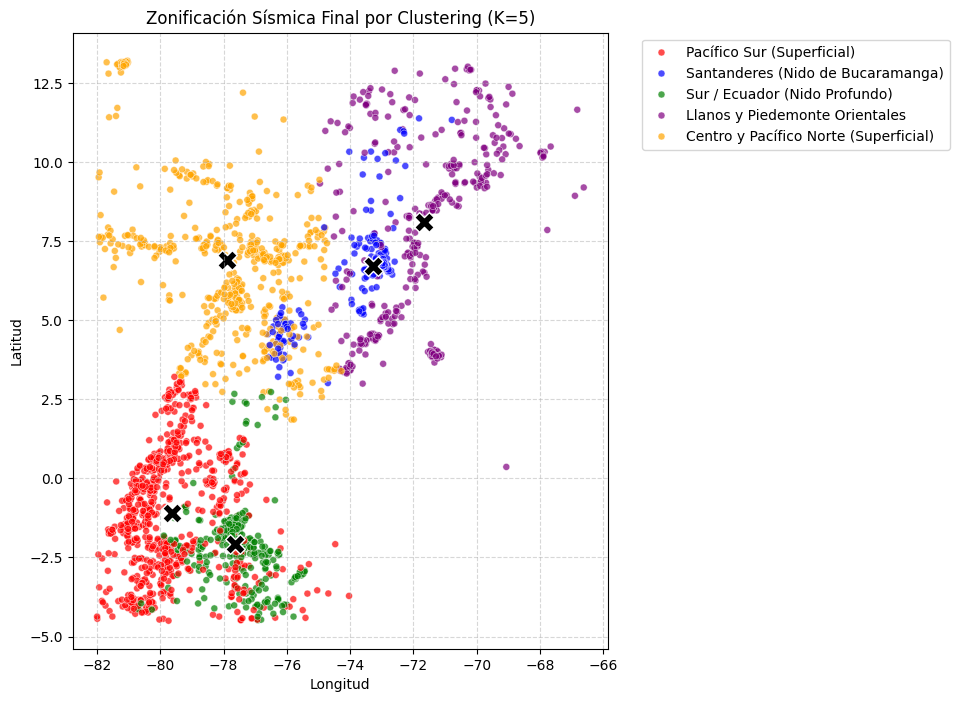

In [ ]:
# 1. Calculate unscaled cluster centroids
unscaled_centroids = scaler.inverse_transform(km_scaled.cluster_centers_)
centroids_df = pd.DataFrame(unscaled_centroids, columns=features)

# 2. Add cluster and cluster_name to centroids_df
centroids_df['cluster'] = range(len(centroids_df))
centroids_df['cluster_name'] = centroids_df['cluster'].map(cluster_names) # Use the same cluster_names mapping

# Create a custom palette based on user feedback
custom_palette = {
    'Llanos y Piedemonte Orientales': 'purple',
    'Santanderes (Nido de Bucaramanga)': 'blue',
    'Centro y Pacífico Norte (Superficial)': 'orange',
    'Pacífico Sur (Superficial)': 'red',
    'Sur / Ecuador (Nido Profundo)': 'green'
}

# 3. Modify the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='cluster_name', palette=custom_palette, s=25, alpha=0.7)
sns.scatterplot(data=centroids_df, x='longitude', y='latitude', color='black',
                marker='X', s=200, edgecolor='white', linewidth=1, legend=False) # Plot centroids with black color
plt.title('Zonificación Sísmica Final por Clustering (K=5)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.gca().set_aspect('equal', adjustable='box') # Proporción real
plt.show()

### 5.3 Hallazgos Finales

**¿Algún cluster captura los sismos de mayor magnitud?**
Sí, el cluster **Centro y Pacífico Norte (Intermedio)** y el de **Sur y Pacífico (Superficial)** tienden a capturar los eventos de mayor magnitud Mw (picos > 6.0). Esto se debe a la acumulación de energía en la zona de subducción de la Placa de Nazca contra la Suramericana.

**Conclusiones pedagógicas:**
- El clúster **Santanderes** identifica perfectamente el Nido con profundidades medias superiores a 150km.
- El clustering espacial 3D es una herramienta poderosa para la UNGRD, permitiendo distinguir riesgos por tsunami (sismos superficiales en el Pacífico) de riesgos por daño estructural profundo (Bucaramanga).